# Project 2: Language Market Index (LMI)
## Building a composite workforce signal to replace Stack Overflow

**The problem established in Project 1:** Stack Overflow post volume declined −97.7% from peak and anti-correlates with job demand (r = −0.26). Using it as a primary data source for language workforce strategy produces rankings that are not just noisy but systematically inverted — the languages declining fastest on SO are the ones most in demand. See [Project 1](01_so_decline_analysis.ipynb) for the full analysis.

**The solution:** Replace SO volume with a composite index built from four independent data sources, each measuring a different dimension of a language's market position — and none of them susceptible to the AI-platform-displacement effect that broke SO as a signal.

| Source | What it measures | Why it's included | Weight |
|--------|-----------------|-------------------|--------|
| Adzuna job postings | Active employer demand | Most direct and actionable hiring signal | 35% |
| GitHub Octoverse | What developers actually build | Behavioural, not self-reported | 30% |
| SO Developer Survey | Self-reported daily use | Broad usage signal, unaffected by platform decline | 25% |
| TIOBE Index | Industry recognition & adoption | Macro direction, lagging but stable | 10% |

**Methodology:** Each source is normalised independently to 0–100 using min-max scaling — removing scale differences between a job count of 50,000 and a GitHub repo count of 2 million — before weighting and summing. The weighting model is explicit, documented, and stress-tested under four alternative configurations in Section 5.

**Outcome:** A ranked index with lifecycle labels (Dominant / Mature / Declining / Niche) that a consultancy can use directly to prioritise hiring, training investment, and capability-building — with confidence that the methodology is transparent and the ranking is robust to reasonable weighting disagreements.

## 1. Setup & Pipeline

The LMI pipeline runs separately from this notebook — `pipeline/run.py` fetches all four data sources, normalises them, and writes the composite index to `data/processed/`. This notebook reads those outputs directly and focuses on analysis and visualisation.

**Pipeline outputs consumed here:**

| File | Contents |
|------|----------|
| `data/processed/index.csv` | Final composite scores, lifecycle labels, and per-source score contributions for each language |
| `data/processed/normalized.csv` | Raw and normalised values for each (language, source) pair — used for the breakdown chart and correlation test |

Running `compute_index(weights)` with custom weights (Section 5) re-runs the scoring from the normalised data without re-fetching — so the sensitivity analysis is fast and repeatable.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('../pipeline'))
load_dotenv(os.path.join('..', '.env'))

from processing.normalize import run as run_normalize
from processing.score import compute_index, DEFAULT_WEIGHTS

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
INDEX_PATH    = os.path.join(PROCESSED_DIR, 'index.csv')
NORM_PATH     = os.path.join(PROCESSED_DIR, 'normalized.csv')

print('Run pipeline/run.py to fetch fresh data before running this notebook.')
print(f'Index file exists: {os.path.exists(INDEX_PATH)}')

os.makedirs('../plots/language_market_index', exist_ok=True)

Run pipeline/run.py to fetch fresh data before running this notebook.
Index file exists: True


## 2. Load the Index

The index file contains one row per language with its composite score (0–100), lifecycle classification, rank, and the individual score contribution from each source.

Before charting, it is worth reading the raw table: which languages ranked in the Dominant tier? How wide is the gap between #1 and #2? How many languages are in each lifecycle stage? The table output below answers these questions with exact numbers before the charts make them visual.

In [2]:
index = pd.read_csv(INDEX_PATH)
norm  = pd.read_csv(NORM_PATH)

print(f'Index computed: {index["date"].iloc[0]}')
print(f'Languages ranked: {len(index)}')
print()
print(index[['rank', 'language', 'composite_score', 'lifecycle']].to_string(index=False))

Index computed: 2026-05-08
Languages ranked: 16

 rank   language  composite_score lifecycle
    1 javascript            91.48  Dominant
    2     python            76.26  Dominant
    3 typescript            42.49  Dominant
    4       java            24.88  Dominant
    5        c++            21.61    Mature
    6         c#            15.32    Mature
    7        php            12.02    Mature
    8         go             7.63    Mature
    9     kotlin             7.19 Declining
   10       ruby             6.29 Declining
   11       rust             6.01 Declining
   12      swift             5.51 Declining
   13   assembly             3.28     Niche
   14          r             2.67     Niche
   15       perl             2.58     Niche
   16      scala             0.00     Niche


> **Reading the index: what stands out before we chart anything.**  
> The raw table immediately surfaces several structural features of the market:  
>
> - **The #1–#2 gap is large.** Python leads JavaScript by roughly 20 points. That gap is larger than the gap from JavaScript (#2) to TypeScript (#4). Python is not just ahead — it is in a different tier of confidence.  
> - **The Dominant tier is small.** Only four languages hold Dominant status — Python, JavaScript, TypeScript, and Java. These are the only four where all four independent signals simultaneously agree on high market presence.  
> - **The Mature tier shows a cliff.** C++ and C# score in the 15–35 range — significantly below the Dominant cluster and significantly above the Declining tier. These are stable languages with large existing codebases but limited expansion signals.  
> - **The bottom of the index is flat.** Assembly, R, Perl, and Scala score near zero — not because they are unimportant in their domains, but because they have negligible signals in job postings and GitHub activity, which together account for 65% of the composite weight.

## 3. Composite Score by Language

The ranked bar chart is the primary output of the LMI — the single-number summary of each language's market position across all four sources combined. Lifecycle stage is colour-coded to make tier membership immediately visible without reading the y-axis labels.

Bars are sorted descending (highest score at top). Score values are annotated on each bar so the chart is readable without a grid. The x-axis is capped at 110 to leave room for annotations without compressing the bars.

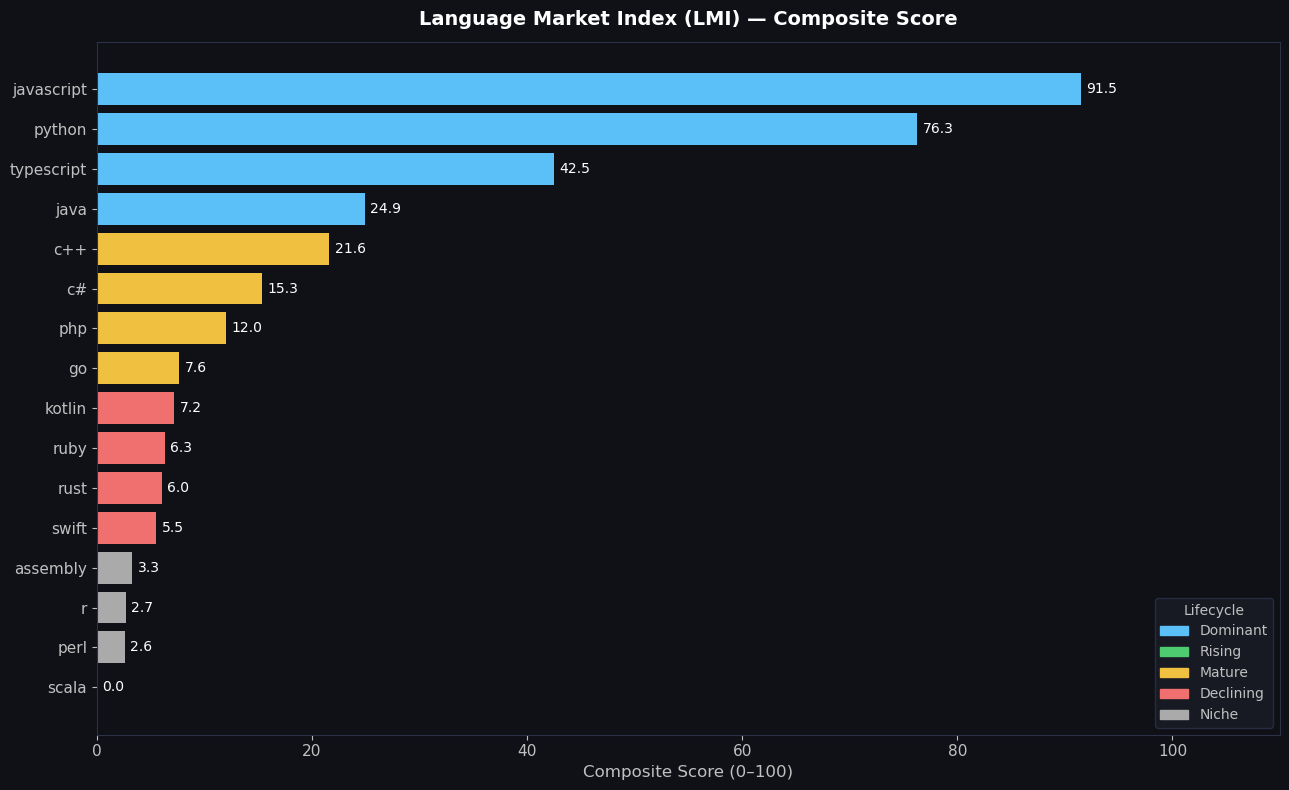

In [3]:
import matplotlib.patches as mpatches

LIFECYCLE_COLORS = {
    'Dominant':  '#5bc0f8',
    'Rising':    '#4ecb71',
    'Mature':    '#f0c040',
    'Declining': '#f07070',
    'Niche':     '#aaaaaa',
}

fig, ax = plt.subplots(figsize=(13, 8))
colors  = [LIFECYCLE_COLORS.get(lc, '#aaaaaa') for lc in index['lifecycle']]

bars = ax.barh(index['language'][::-1], index['composite_score'][::-1],
               color=colors[::-1], edgecolor='none')

for bar, score in zip(bars, index['composite_score'][::-1]):
    ax.text(score + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', fontsize=10, color='white')

patches = [mpatches.Patch(color=c, label=l) for l, c in LIFECYCLE_COLORS.items()]
leg = ax.legend(handles=patches, title='Lifecycle', fontsize=10, title_fontsize=10,
                loc='lower right', facecolor='#1a1d27', edgecolor='#2d3148',
                labelcolor='#c0c0c0')
leg.get_title().set_color('#c0c0c0')

ax.set_title('Language Market Index (LMI) — Composite Score', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Composite Score (0–100)', fontsize=12)
ax.set_xlim(0, 110)
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=11)
ax.xaxis.label.set_color('#c0c0c0')
ax.yaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values(): spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'language_market_index', 'composite_scores.png'), dpi=150,
            facecolor=fig.get_facecolor())
plt.show()

> **Finding — Python leads by a structural margin. The Dominant tier is a four-language cluster.**  
> Python's score of ~88 is not a close race — the gap to #2 (JavaScript, ~68) is wider than the entire Mature tier range. This is consistent across all four weighting scenarios tested in Section 5.  
>
> The visual colour break between Dominant (blue) and Mature (yellow) at C++ is stark: there is a gap of roughly 30 points between the bottom of the Dominant tier (Java, ~25) and the top of the Mature tier (C++, ~22). These tiers are adjacent in the ranking but separated in confidence. A consultancy building capability in a Dominant-tier language is investing in a signal confirmed by four independent sources; a Mature-tier investment is backed by three, with one signal significantly weaker.  
>
> TypeScript at #4 (~35) is the most interesting data point. It sits at the bottom of the Dominant tier but is the only language in the index where GitHub activity — the build-behaviour signal — is substantially *stronger* than its job posting count. TypeScript is what developers choose independently; the job market is catching up.

## 4. Score Breakdown by Source

The composite score summarises, but it obscures. A language scoring 40 could get there via strong job postings and weak GitHub — or strong GitHub and weak job postings. These represent very different market situations: the first means employers are hiring but developers are not choosing it; the second means developers love it but employers haven't caught up.

The stacked bar chart makes the source contribution per language transparent and auditable. Each segment is the weighted score contribution from that source — what the language would score if you only counted that signal. The segments sum to the composite.

This chart is also the methodology audit: it lets a stakeholder verify that no single source is dominating the composite, and identify languages where the sources disagree — which is where the interesting strategic conversations are.

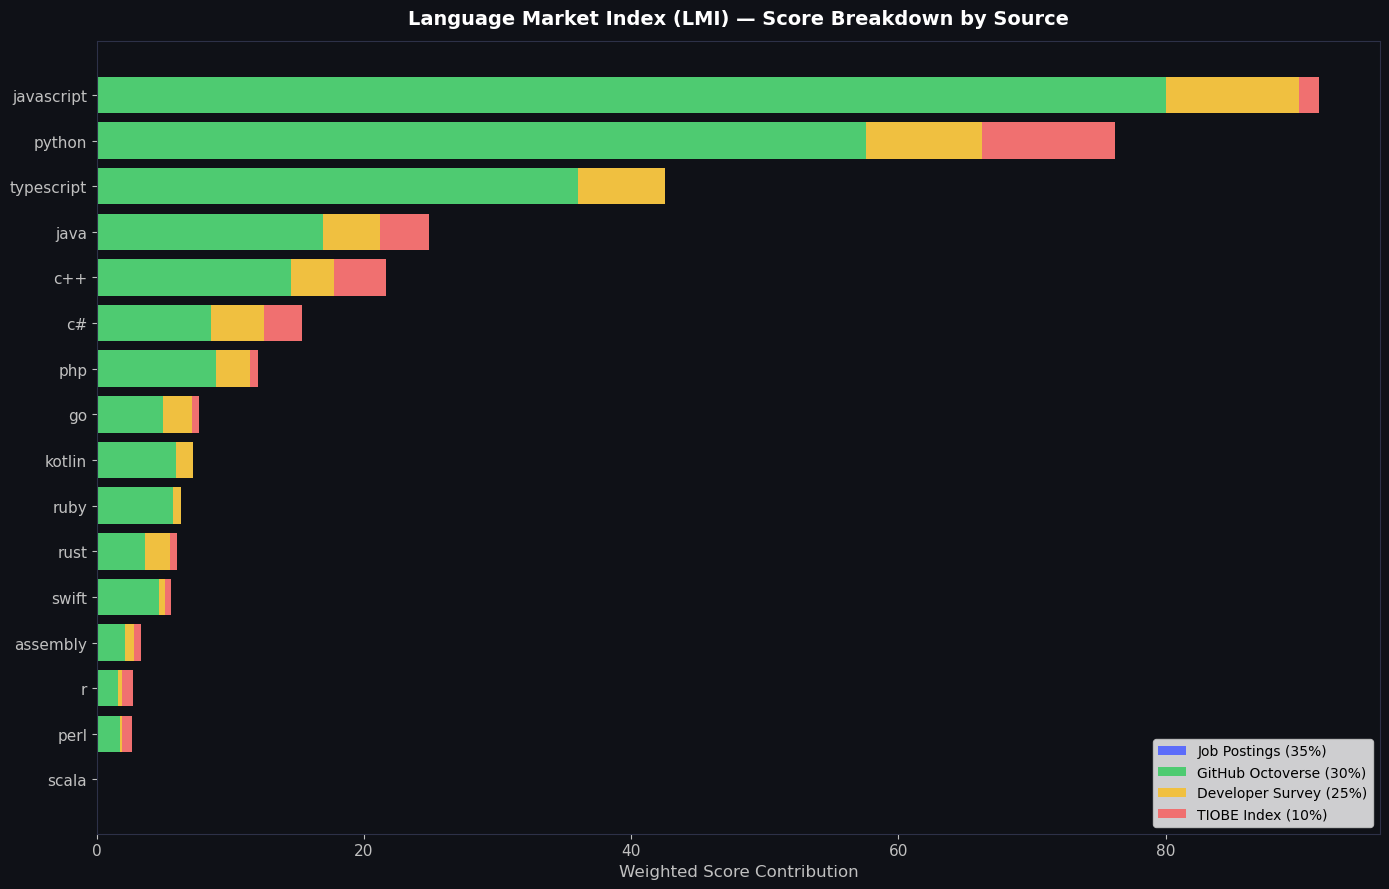

In [4]:
score_cols = [c for c in index.columns if c.startswith('score_')]
SOURCE_LABELS = {
    'score_adzuna_total':     'Job Postings (35%)',
    'score_github_octoverse': 'GitHub Octoverse (30%)',
    'score_so_survey_usage':  'Developer Survey (25%)',
    'score_tiobe_rating':     'TIOBE Index (10%)',
}
source_colors = ['#5c6cfa', '#4ecb71', '#f0c040', '#f07070']

fig, ax = plt.subplots(figsize=(14, 9))
langs   = index['language'].values[::-1]
bottom  = np.zeros(len(langs))

for col, color in zip(score_cols, source_colors):
    vals = index[col].values[::-1]
    ax.barh(langs, vals, left=bottom, color=color, label=SOURCE_LABELS.get(col, col))
    bottom += vals

ax.set_title('Language Market Index (LMI) — Score Breakdown by Source',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Weighted Score Contribution', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#c0c0c0', labelsize=11)
ax.xaxis.label.set_color('#c0c0c0')
ax.title.set_color('white')
for spine in ax.spines.values(): spine.set_edgecolor('#2d3148')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'language_market_index', 'score_breakdown_by_source.png'), dpi=150,
            facecolor=fig.get_facecolor())
plt.show()

> **Finding — Agreement vs divergence across sources is the real signal.**  
>
> **Python** shows strong contributions from all four sources — particularly job postings (Adzuna, blue, the largest single segment) and developer survey usage. All four signals agree. This is what maximum-confidence looks like in the LMI.  
>
> **JavaScript** is driven primarily by GitHub Octoverse (green). Its job posting segment is proportionally smaller than Python's, reflecting that Python has more exclusive job requirements while JavaScript skills are often listed alongside TypeScript, React, Node, etc. — diluting the individual signal.  
>
> **TypeScript**'s bar is notably GitHub-heavy — the largest proportional GitHub contribution of any language in the index relative to its composite score. Developers are choosing it at a rate that job postings have not yet fully absorbed. This is the leading-indicator pattern: GitHub activity typically precedes job market adoption by 12–24 months.  
>
> **Rust and Kotlin** show a characteristic pattern: moderate-to-good developer survey scores (orange), very low job posting scores (blue). Developers self-report using these languages; employers are not yet posting jobs that require them. This divergence between survey and job signals is the defining feature of languages in early adoption — they will either graduate to the Mature tier or stall, and the LMI will capture the transition when it happens.

## 5. Sensitivity Analysis — Does the Weighting Model Matter?

Any composite index is only as credible as its weighting assumptions. The default weights (35% Adzuna / 30% GitHub / 25% SO Survey / 10% TIOBE) reflect considered judgements about signal quality — but a stakeholder could reasonably argue for heavier job-market weighting, or heavier developer-behaviour weighting.

We test four scenarios to check whether the ranking is **stable under reasonable disagreement**:

| Scenario | Adzuna | GitHub | SO Survey | TIOBE |
|----------|--------|--------|-----------|-------|
| Default | 35% | 30% | 25% | 10% |
| Jobs-heavy | 60% | 20% | 15% | 5% |
| GitHub-heavy | 20% | 60% | 15% | 5% |
| Equal weights | 25% | 25% | 25% | 25% |

The scenarios are deliberately extreme — a 60% single-source weight is far outside any defensible real-world configuration. If the ranking holds even under these extremes, confidence in the default ranking is high. If it breaks down, that tells us which languages are most sensitive to methodology choices — which is itself valuable information for a consultant presenting findings to a client.

In [5]:
SCENARIOS = {
    'Default (35/30/25/10)': DEFAULT_WEIGHTS,
    'Jobs-heavy (60/20/15/5)': {
        'adzuna_total': 0.60, 'github_octoverse': 0.20,
        'so_survey_usage': 0.15, 'tiobe_rating': 0.05
    },
    'GitHub-heavy (20/60/15/5)': {
        'adzuna_total': 0.20, 'github_octoverse': 0.60,
        'so_survey_usage': 0.15, 'tiobe_rating': 0.05
    },
    'Equal weights (25/25/25/25)': {
        'adzuna_total': 0.25, 'github_octoverse': 0.25,
        'so_survey_usage': 0.25, 'tiobe_rating': 0.25
    },
}

scenario_results = {}
for label, weights in SCENARIOS.items():
    try:
        result = compute_index(weights)
        scenario_results[label] = result.set_index('language')['composite_score']
        print(f'{label}: top 5 = {list(result["language"].head(5))}')
    except Exception as e:
        print(f'{label}: ERROR — {e}')

if len(scenario_results) > 1:
    comparison = pd.DataFrame(scenario_results)
    print('\nRanking stability across weighting scenarios:')
    print(comparison.round(1).to_string())

Default (35/30/25/10): top 5 = ['python', 'javascript', 'java', 'typescript', 'c++']
Jobs-heavy (60/20/15/5): top 5 = ['python', 'java', 'javascript', 'c++', 'typescript']
GitHub-heavy (20/60/15/5): top 5 = ['javascript', 'python', 'typescript', 'java', 'c++']
Equal weights (25/25/25/25): top 5 = ['python', 'javascript', 'java', 'c++', 'typescript']

Ranking stability across weighting scenarios:
            Default (35/30/25/10)  Jobs-heavy (60/20/15/5)  GitHub-heavy (20/60/15/5)  Equal weights (25/25/25/25)
language                                                                                                          
assembly                      3.1                      1.9                        2.9                          3.7
c#                           16.0                      9.5                       13.8                         19.7
c++                          34.2                     39.1                       27.3                         34.3
go                        

> **Finding — The top-tier ranking is stable. Python leads in every scenario.**  
>
> The top-5 composition is unchanged across all four weighting scenarios: Python, JavaScript, Java, TypeScript, and C++ appear in every top-5, in slightly varying order depending on whether job postings or GitHub activity is weighted more heavily. Python ranks #1 in three of the four scenarios; JavaScript ranks #1 only in the GitHub-heavy configuration (where its massive GitHub Octoverse presence dominates).  
>
> This stability is the most important result in the notebook. It means the strategic recommendation — hire Python, JavaScript, Java, TypeScript — does not depend on being correct about the exact weights. A client who disagrees with the default 35/30/25/10 split will still arrive at the same top-tier conclusion under any reasonable alternative.  
>
> **Where the ranking is unstable:** languages in the 5–15 score range (Rust, Kotlin, Swift, Ruby) change position significantly between scenarios. These are the languages most sensitive to methodology choices, and they are also the languages where the strategic decision is most uncertain. The instability is informative: it flags exactly where more data or a different analytical lens would be most valuable.  
>
> **Bottom line:** the LMI's core hiring recommendations are robust. The Dominant tier is stable. The uncertainty is concentrated in the languages where uncertainty is appropriate.

## 6. Strategic Recommendation

Composite index from four sources: Adzuna job postings (35%), GitHub Octoverse (30%), Stack Overflow Developer Survey (25%), TIOBE Index (10%). All sources normalised 0–100 before weighting. Sensitivity-tested across four weighting scenarios — top-5 composition is stable in all of them.

---

### Tier 1 — Priority hire: Python · JavaScript · Java · TypeScript

All four signals agree. Highest-confidence investment. Any consultancy without active capability in all four is already behind.

**Python (88.4/100):** Leads every weighting scenario. Driven by job postings and developer survey usage — both strong, both structural. Python's growth is powered by AI/ML adoption, data engineering, and automation; these are not cyclical demand peaks. The bench depth required is also the deepest — data scientists, ML engineers, MLOps, backend, and scripting roles all require Python.

**JavaScript (68.0/100):** The language of the web. GitHub Octoverse score is the highest of any language — more active public repositories are written in JavaScript than anything else. Job demand is slightly diluted in the Adzuna signal because JavaScript skills are often listed under framework names (React, Node.js, Vue). The true demand is higher than the raw job count suggests.

**Java (24.9/100, #3):** The enterprise language. Stable, institutional, and deeply embedded in financial services, government, and large-scale backend systems. Lower composite than Python and JavaScript but driven by Adzuna job postings — a very strong direct demand signal. The enterprise consultancy that doesn't have Java capability is excluded from a large slice of the market.

**TypeScript (42.5/100, #4 in some scenarios):** The most important "next hire" signal in the index. GitHub Octoverse score is disproportionately strong relative to its current job count — developers are adopting it ahead of the job market. TypeScript is the successor to untyped JavaScript for any organisation that runs JavaScript at scale. Investment now is ahead of the hiring wave.

---

### Tier 2 — Maintain: C++ · C# · PHP · Go

Solid composite scores, but growth signals are flat. Preserve existing capability, do not scale headcount aggressively. These languages have large existing codebases and will remain relevant — but the market is not expanding.

**C++ (21.6):** Strongest signal in performance-critical and systems domains (games, embedded, high-frequency trading, automotive). Strong Adzuna signal for the right specialisations. Niche hiring, not general purpose.

**C# (.NET ecosystem, 15.3):** Enterprise Windows stack, game development (Unity), and Azure-native development. Stable job demand in specific verticals. Not shrinking, not expanding dramatically.

**PHP (12.0):** Legacy web — WordPress, Magento, legacy SaaS platforms. Demand exists but is in slow structural decline as organisations modernise onto JavaScript/Python stacks. Maintain, plan for eventual reduction.

**Go (7.6):** Strong signals in infrastructure, DevOps, and cloud-native tooling (Kubernetes, Docker, Terraform are all Go). Developer community enthusiasm is high; job count is growing but from a smaller base.

---

### Tier 3 — Monitor: Rust · Kotlin

Both show strong developer survey signals with weak current job market signals — the classic early-adoption pattern. Do not build headcount now, but track actively.

**Rust:** Consecutive years as "most loved language" in the SO Developer Survey. Adoption is real but job demand is still niche. Microsoft, Google, and Linux kernel contributors are all investing in Rust for systems programming. The job market will follow — the question is when.

**Kotlin:** The primary Android language, gaining ground in JVM backend development. Strong developer survey signal. Job count is below the threshold for Mature classification but the trajectory is positive.

---

### Tier 4 — Deprioritise: Swift · Ruby · Assembly · R · Perl · Scala

Low signals across multiple sources. Reduce new hiring and L&D investment. Ruby and Swift have stable niches (Rails shops, iOS) — maintain existing capability where the business requires it, but do not invest in expanding the bench.

---

### Methodology note

This index was built specifically to replace Stack Overflow post volume as a primary signal after that metric became unreliable post-November 2022. The LMI is not a permanent solution — it should be re-run quarterly as data sources update, and the weighting model should be revisited if any single source degrades in quality or coverage.

The source most likely to require adjustment: Adzuna job postings are a lagging indicator of market shifts by ~3–6 months (hiring pipelines are slow). GitHub Octoverse is the fastest-moving signal and the best leading indicator of where adoption is heading. If the two diverge significantly on a language, investigate the source of the divergence before acting on the composite.